# MIT 15.776: Hands-On Deep Learning
## Final Project: Disaster Tweets Analysis

**Giuseppe Iannone, Luca Sfragara, Trisha Sutivong, Hanna Zhang**

This notebook contains our exploration of NLP models to classify tweets into real (1) and fake (0) announcements of disaster.



In [ ]:
!pip install keras_tuner

In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import keras_tuner as kt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
keras.utils.set_random_seed(42) # setting seed
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


## Step 0: Loading Data
The data set comprises of 7,613 labeled tweets for training and 3,263 unlabeled tweets for evaluation. Each instance contains:
- Text: The tweet content (max 280 characters)
- Keyword: Optional disaster-related keyword (e.g., “wildfire”, “earthquake”)
- Location: Optional user-provided location information
- Target: Binary label (1 = real disaster, 0 = not a disaster)

Because the test set given by competition is unlabeled, we will separate our training set into train, validation and test sets. We will use training set to train, validation to perform cross-validation and test set to evaluate our final performance in this assignment.

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# separate out test set
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    train_df['text'].values,
    train_df['target'].values,
    test_size=0.15,  # 15% for test set
    random_state=42,
    stratify=train_df['target'].values
)

# split remaining train into train (68%) and validation (17%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.2,  # 20% of remaining
    random_state=42,
    stratify=train_val_labels
)

# print sizes of all sets
print("train set size: ", len(train_texts))
print("validation set size: ", len(val_texts))
print("test set size: ", len(test_texts))
print("submission set size (not used in this assignment): ", len(test_df))
print("example data: ")
print(train_df.head()) # looking at data

train set size:  5176
validation set size:  1295
test set size:  1142
submission set size (not used in this assignment):  3263
example data: 
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


## Step 1: Defining Evaluation Metric and Naive Baseline
Following Kaggle's competition guidelines, we define four standard classifcation evaluation metrics we will use to assess our model performance: f1 score, accuracy, precision and recall. We define two functions for easy printing in the future and establish the baseline, i.e., model that predicts the most common class.

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return {
        'model': model_name,
        'f1': f1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall
    }

def print_results(list_dicts):
    models = [d['model'] for d in list_dicts]
    print(f"\n{'Metric':<12}", end="")
    for model in models:
        print(f"{model:<15}", end="")
    print()
    for metric in ['f1', 'accuracy', 'precision', 'recall']:
        print(f"{metric:<12}", end="")
        for d in list_dicts:
            print(f"{d[metric]:<15.4f}", end="")
        print()

In [ ]:
master_list = [] # create list for future models
# examine distribution of labels in data
print("Target distribution in data:")
counts = train_df['target'].value_counts()
percentages = train_df['target'].value_counts(normalize=True) * 100
print(f"fake: {counts[0]} ({percentages[0]:.2f}%)")
print(f"real: {counts[1]} ({percentages[1]:.2f}%)")

# baseline - what is our accuracy score if we predict the most common class?
most_common = train_df['target'].mode()[0]
baseline_pred = np.full(len(test_labels), most_common)
# evaluate baseline
baseline_metrics = evaluate_model(test_labels, baseline_pred,"Baseline")
master_list.append(baseline_metrics)
print_results(master_list)

Target distribution in data:
fake: 4342 (57.03%)
real: 3271 (42.97%)

Metric      Baseline       
f1          0.0000         
accuracy    0.5701         
precision   0.0000         
recall      0.0000         


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 2: NLP Models From Scratch

We first start with some standard models learned in class. This includes Bag of Words model, and Bag of Words with hyperparameter tuning through grid search.

In [ ]:
NUM_EPOCHS = 5 # from qualitative observation val accuracy drops after this

#### MODEL 1: Basic Bag of Words

In [ ]:
# MODEL 1: Basic Bag of Words

# vectorizing tweets
max_tokens = 5000 # tunable
text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "multi_hot"
)
text_vectorization.adapt(train_texts)
X_train = text_vectorization(train_texts)
X_val = text_vectorization(val_texts)
X_test = text_vectorization(test_texts)
# defining targets
y_train = train_labels
y_val = val_labels
y_test = test_labels

# build model
inputs = keras.layers.Input(shape = (max_tokens,))
x = keras.layers.Dense(8, activation = "relu")(inputs)
# since binary classification, can use sigmoid
outputs = keras.layers.Dense(1, activation = "sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy", # since two classes
    metrics=["accuracy"]
)

history = model.fit(
    x = X_train,
    y = y_train,
    validation_data = (X_val, y_val),
    epochs = NUM_EPOCHS,
    batch_size = 32
)

# evaluate on test set (final evaluation)
test_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
bow_metrics = evaluate_model(y_test, test_pred, model_name = "BoW")
master_list.append(bow_metrics)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        40,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,017 (156.32 KB)

 Trainable params: 40,017 (156.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6611 - loss: 0.6643 - val_accuracy: 0.8062 - val_loss: 0.5446
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8220 - loss: 0.4982 - val_accuracy: 0.8201 - val_loss: 0.4618
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8555 - loss: 0.3930 - val_accuracy: 0.8224 - val_loss: 0.4364
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.3316 - val_accuracy: 0.8201 - val_loss: 0.4328
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8979 - loss: 0.2876 - val_accuracy: 0.8131 - val_loss: 0.4386
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


#### MODEL 2: Bag of Words with Hyperparameter Optimization

In [ ]:
# MODEL 2: Bag of Words with Hyperparameter Optimization
# code from class to tune hyperparameter
def build_model(hp):
    input = keras.layers.Input(shape = X_train.shape[1:])
    x = input

    for i in range(hp.Int("num_layers", 1, 2)):  # varying number of layers
        x = keras.layers.Dense(
            units=hp.Choice(f"units_{i}", [8, 16, 32]),  # varying number of units
            activation="relu")(x)
        x = keras.layers.Dropout(hp.Choice("dropout", [0.0, 0.2, 0.5]))(x)  # varying dropout to prevent overfitting

    output = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(input, output)
    model.compile(
        # varying learning rate
        optimizer=keras.optimizers.Adam(hp.Choice("learning_rate", [1e-3, 1e-4])),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# a tuner that will search for best parameter value
# 1 layer: 3 units × 3 dropout × 2 learning rate = 18 models
# 2 layers: 3 x 3 units × 3 dropout × 2 learning rates = 54 models
# in total we search over 72 models
tuner = kt.GridSearch(
    build_model,
    objective="val_accuracy",
    overwrite=True
)

tuner.search_space_summary()

tuner.search(X_train,
             y_train,
             epochs = NUM_EPOCHS,
             batch_size = 32,
             verbose = 1,
             validation_data=(X_val, y_val))

Trial 72 Complete [00h 00m 09s]
val_accuracy: 0.7204633355140686

Best val_accuracy So Far: 0.8324324488639832
Total elapsed time: 00h 09m 09s


In [ ]:
best_model = tuner.get_best_models(1)[0]
test_pred = (best_model.predict(X_test) > 0.5).astype(int).flatten()
bowt_metrics = evaluate_model(y_test, test_pred, model_name = "BoW (Tuned)")
master_list.append(bowt_metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [ ]:
print_results(master_list)


Metric      Baseline       BoW            BoW (Tuned)    
f1          0.0000         0.7571         0.7685         
accuracy    0.5701         0.7977         0.8170         
precision   0.0000         0.7826         0.8422         
recall      0.0000         0.7332         0.7067         


## Step 3.1: Leveraging Feature Engineering

Given that we only have text information, we thought it could be interesting to see if we could supplement our dataset with some other useful information. We account for numerical characteristics of tweets to give more insights into how they are correlated with whether it is real or not.

feature statistics by target:
        char_count  word_count  avg_word_length  hashtag_count  mention_count  \
target                                                                          
0        95.585366   14.636856         5.879647       0.379404       0.409214   
1       108.389838   15.172212         6.484011       0.517086       0.276978   

        url_count  uppercase_count  
target                              
0        0.513889         0.708333  
1        0.780576         0.745504  


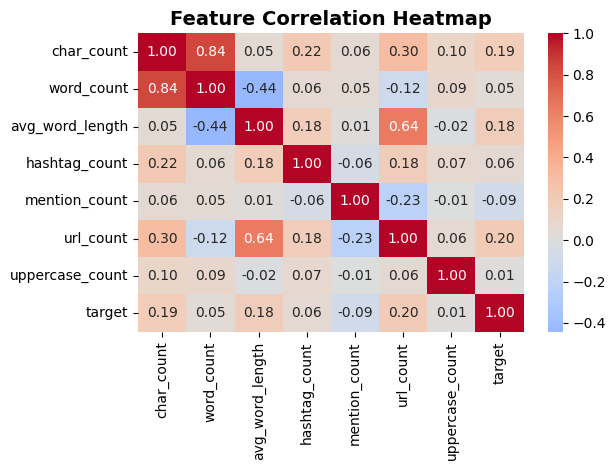


Features correlation with target (sorted):
target             1.000000
url_count          0.199150
char_count         0.187253
avg_word_length    0.179646
hashtag_count      0.062658
word_count         0.046487
uppercase_count    0.009534
mention_count     -0.092375
Name: target, dtype: float64


In [ ]:
# to preserve integrity we recreate dataframes from already split data set
train_df_split = pd.DataFrame({'text': train_texts, 'target': train_labels})
val_df_split = pd.DataFrame({'text': val_texts, 'target': val_labels})
test_df_split = pd.DataFrame({'text': test_texts, 'target': test_labels})

# create some new numerical features
def create_text_features(df):
    df['char_count'] = df['text'].apply(len)
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
    df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(word) for word in str(x).split()]))
    df['hashtag_count'] = df['text'].apply(lambda x: len([word for word in str(x).split() if word.startswith('#')]))
    df['mention_count'] = df['text'].apply(lambda x: len([word for word in str(x).split() if word.startswith('@')]))
    df['url_count'] = df['text'].apply(lambda x: len([word for word in str(x).split() if 'http' in word.lower()]))
    df['uppercase_count'] = df['text'].apply(lambda x: len([word for word in str(x).split() if word.isupper() and len(word) > 1]))
    return df

# apply features
train_df_split = create_text_features(train_df_split)
val_df_split = create_text_features(val_df_split)
test_df_split = create_text_features(test_df_split)

# display statistics statistics
feature_cols = ['char_count', 'word_count', 'avg_word_length',
                'hashtag_count', 'mention_count', 'url_count', 'uppercase_count']
print("feature statistics by target:")
print(train_df_split.groupby('target')[feature_cols].mean())

# because these are numerical features, we can also get correlation with target
correlation_features = feature_cols + ['target']
correlation_matrix = train_df_split[correlation_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nFeatures correlation with target (sorted):")
print(correlation_matrix['target'].sort_values(ascending=False))

#### MODEL 3: Bag of Words with Hyperparam Optimization and Feature Engineering

In [ ]:
# MODEL 3: Bag of Words with Hyperparam Optimization and Feature Engineering
# we repeat the same grid search as earlier but now with a new data set
# vectorizing tweets from the split data

max_tokens = 5000
text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "multi_hot"
)
text_vectorization.adapt(train_texts)
X_train = text_vectorization(train_texts)
X_val = text_vectorization(val_texts)
X_test = text_vectorization(test_texts)

# defining targets
y_train = train_labels
y_val = val_labels
y_test = test_labels

# hyperparameter tuning function
def build_model(hp):
    input = keras.layers.Input(shape = X_train.shape[1:])
    x = input

    for i in range(hp.Int("num_layers", 1, 2)):  # varying number of layers
        x = keras.layers.Dense(
            units=hp.Choice(f"units_{i}", [8, 16, 32]),  # varying number of units
            activation="relu")(x)
        x = keras.layers.Dropout(hp.Choice("dropout", [0.0, 0.2, 0.5]))(x)  # varying dropout to prevent overfitting

    output = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(input, output)
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice("learning_rate", [1e-3, 1e-4])),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# tuner setup
tuner = kt.GridSearch(
    build_model,
    objective="val_accuracy",
    overwrite=True
)

tuner.search_space_summary()
tuner.search(X_train,
             y_train,
             epochs = NUM_EPOCHS,
             batch_size = 32,
             verbose = 1,
             validation_data=(X_val, y_val))

Trial 72 Complete [00h 00m 09s]
val_accuracy: 0.7374517321586609

Best val_accuracy So Far: 0.8301158547401428
Total elapsed time: 00h 09m 52s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
test_pred = (best_model.predict(X_test) > 0.5).astype(int).flatten()
bowt_fe = evaluate_model(y_test, test_pred, model_name = "BoW (FE/Tuned)")
master_list.append(bowt_fe)
print_results(master_list)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Metric      Baseline       BoW            BoW (Tuned)    BoW (FE/Tuned) 
f1          0.0000         0.7571         0.7685         0.7709         
accuracy    0.5701         0.7977         0.8170         0.8179         
precision   0.0000         0.7826         0.8422         0.8393         
recall      0.0000         0.7332         0.7067         0.7128         


## Step 3.2: Leveraging Transformers Encoding

Going to more advanced models, we explore transformer encoding to capture context in the tweet. This is especially important as these tweets may have similar words but the context might be the differentiating factor for whether it is a real disaster or not: take "fire" in different contexts as an example.

In [ ]:
from keras import ops
from keras import layers
from keras import ops

In [ ]:
# importing keras subclassing API similar to recitation
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim,
                                             output_shape=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(dense_dim, activation = "relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + ffn_output)


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = ops.shape(x)[-1]
        positions = ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [ ]:
# transformer params
max_tokens = 5000 # maximum vocab
max_length = 100  # maximum sequence length
embed_dim = 64   # number of elements of the embedding vectors
num_heads = 4    # number of heads inside the multi-head attention
dense_dim = 128  # how many relus in the hidden layer

#### MODEL 4: Transformer Encoding (No Feature Engineering)

In [ ]:
# MODEL 4: Transformer Encoding (No Feature Engineering)
text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "int",
    output_sequence_length = max_length
)

text_vectorization.adapt(train_texts)

X_train = text_vectorization(train_texts)
X_val = text_vectorization(val_texts)
X_test = text_vectorization(test_texts)
y_train = train_labels
y_val = val_labels
y_test = test_labels

inputs = keras.layers.Input(shape=(max_length,))
# convert word indices to embeddings + add position info
embedding = TokenAndPositionEmbedding(max_length, max_tokens, embed_dim)
x = embedding(inputs) # the grey encoder before being contextualized
# contextualizing the embedding, this is the blue vector
encoder_out = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)

# aggregating the sequence of words into a single vector
x = keras.layers.GlobalAveragePooling1D()(encoder_out) # average treats all positions the same

# standard classifier
x = keras.layers.Dense(128, activation = "relu")(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation = "sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

model.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics =[ "accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = NUM_EPOCHS,
    batch_size = 32
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 100, 64)        │       326,400 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 100, 64)        │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,049 (1.59 MB)

 Trainable params: 418,049 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 53s 186ms/step - accuracy: 0.5464 - loss: 0.6992 - val_accuracy: 0.5707 - val_loss: 0.6709
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7297 - loss: 0.5545 - val_accuracy: 0.8046 - val_loss: 0.4525
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 0.3562 - val_accuracy: 0.7969 - val_loss: 0.5105
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9015 - loss: 0.2587 - val_accuracy: 0.7946 - val_loss: 0.6513
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9336 - loss: 0.1912 - val_accuracy: 0.7830 - val_loss: 0.8444


In [ ]:
# evaluate results
test_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
transformer_base = evaluate_model(y_test, test_pred, model_name="Transformer")
master_list.append(transformer_base)

36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step


#### MODEL 5: Transformer Encoding (With Feature Engineering)

In [ ]:
# MODEL 5: Transformer Encoding (With Feature Engineering)
text_vectorization = keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "int",
    output_sequence_length = max_length
)

text_vectorization.adapt(train_texts)

X_train = text_vectorization(train_texts)
X_val = text_vectorization(val_texts)
X_test = text_vectorization(test_texts)
y_train = train_labels
y_val = val_labels
y_test = test_labels

# extract engineered features from dataframes
X_train_features = train_df_split[feature_cols].values
X_val_features = val_df_split[feature_cols].values
X_test_features = test_df_split[feature_cols].values

# text input
text_input = keras.layers.Input(shape=(max_length,), name="text")
# feature input
feature_input = keras.layers.Input(shape=(len(feature_cols),), name="features")

# convert word indices to embeddings + add position info
embedding = TokenAndPositionEmbedding(max_length, max_tokens, embed_dim)
x = embedding(text_input) # the grey encoder before being contextualized
# contextualizing the embedding, this is the blue vector
encoder_out = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)

# aggregating the sequence of words into a single vector
x = keras.layers.GlobalAveragePooling1D()(encoder_out) # average treats all positions the same

# combine transformer output with engineered features
combined = keras.layers.Concatenate()([x, feature_input])

# standard classifier
x = keras.layers.Dense(128, activation = "relu")(combined)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation = "sigmoid")(x)
model = keras.Model(inputs=[text_input, feature_input], outputs=outputs)
model.summary()

model.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])

history = model.fit(
    [X_train, X_train_features], y_train,
    validation_data = ([X_val, X_val_features], y_val),
    epochs = 8, # adjusted since transformer seems to take longer to learn
    batch_size = 32
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 100, 64)   │    326,400 │ text[0][0]        │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 100, 64)   │     83,200 │ token_and_positi… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 71)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      9,216 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 418,945 (1.60 MB)

 Trainable params: 418,945 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.5004 - loss: 1.7322 - val_accuracy: 0.5645 - val_loss: 0.6680
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5635 - loss: 0.9939 - val_accuracy: 0.5676 - val_loss: 0.6866
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6139 - loss: 0.7802 - val_accuracy: 0.7344 - val_loss: 0.6882
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7762 - loss: 0.5124 - val_accuracy: 0.7846 - val_loss: 0.5137
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8640 - loss: 0.3453 - val_accuracy: 0.7807 - val_loss: 0.6385
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9078 - loss: 0.2487 - val_accuracy: 0.7737 - val_loss: 0.7738
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9359 - loss: 0.1818 - val_accuracy: 0.7714 - val_loss: 0.9320
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9486 - loss: 0.1411 - val_accuracy: 0.7498 -

In [ ]:
# evaluate on test set
test_pred = (model.predict([X_test, X_test_features]) > 0.5).astype(int).flatten()
transformer_fe = evaluate_model(y_test, test_pred, model_name = "Transformer (FE)")
master_list.append(transformer_fe)

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


In [ ]:
print_results(master_list)


Metric      Baseline       BoW            BoW (Tuned)    BoW (FE/Tuned) Transformer    Transformer (FE)
f1          0.0000         0.7571         0.7685         0.7709         0.7041         0.6800         
accuracy    0.5701         0.7977         0.8170         0.8179         0.7601         0.7067         
precision   0.0000         0.7826         0.8422         0.8393         0.7494         0.6403         
recall      0.0000         0.7332         0.7067         0.7128         0.6640         0.7251         


## Step 3.2: Leveraging Pre-Trained Models (BERT)

#### Model 6 RoBERTa (torch)

In [ ]:
# imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Universal Dataset for HF Transformers
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Universal Training Function
def train_hf_model(
    model_name,
    X_train, y_train,
    X_val, y_val,
    batch_size=16,
    lr=2e-5,
    epochs=4,
    max_len=128
):

    print(f"\n===== Training {model_name} =====")

    # Load tokenizer + model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    ).to(device)

    # Datasets
    train_dataset = TransformerDataset(X_train, y_train, tokenizer, max_len)
    val_dataset   = TransformerDataset(X_val, y_val, tokenizer, max_len)

    # Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = len(train_loader) * epochs
    warmup_steps = total_steps // 10  # 10% warmup

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Tracking best F1
    best_f1 = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    # Training Loop
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 50)

        # ---------- TRAINING ----------
        model.train()
        total_train_loss = 0

        progress = tqdm(train_loader, desc="Training")
        for batch in progress:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            progress.set_postfix({"loss": total_train_loss / (progress.n+1)})

        avg_train_loss = total_train_loss / len(train_loader)



        # ---------- VALIDATION ----------
        model.eval()
        total_val_loss = 0
        preds, trues = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss = outputs.loss
                total_val_loss += val_loss.item()

                logits = outputs.logits
                predictions = torch.argmax(logits, dim=1)

                preds.extend(predictions.cpu().numpy())
                trues.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(trues, preds)
        val_f1  = f1_score(trues, preds)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        # Save best
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"best_{model_name.replace('/', '_')}.pt")
            print(f"✓ Saved best model with F1 = {best_f1:.4f}")

    print("\nTraining completed!")
    print(f"Best F1 for {model_name}: {best_f1:.4f}")

    return model, tokenizer, history


# Final Prediction Function
def predict_hf(model, tokenizer, texts, batch_size=16, max_len=128):
    dataset = TransformerDataset(texts, [0]*len(texts), tokenizer, max_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    preds = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

    return np.array(preds)

# returns probability P(class=1) for HuggingFace models
def predict_hf_proba(model, tokenizer, texts, batch_size=16):
    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(device)

            outputs = model(**enc)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1]  # class=1 probability
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_probs)


Using device: cuda


In [ ]:
roberta_model, roberta_tokenizer, roberta_hist = train_hf_model(
    model_name="roberta-base",
    X_train=train_texts, y_train=train_labels,
    X_val=val_texts, y_val=val_labels,
    batch_size=16,
    lr=2e-5,
    epochs=4
)



===== Training roberta-base =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Train Loss: 0.3658
Val Loss: 0.4081 | Val Acc: 0.8378 | Val F1: 0.8077
✓ Saved best model with F1 = 0.8077

Epoch 3/4
--------------------------------------------------


Evaluating: 100%|██████████| 81/81 [00:02<00:00, 31.47it/s]


Train Loss: 0.2909
Val Loss: 0.4454 | Val Acc: 0.8402 | Val F1: 0.8103
✓ Saved best model with F1 = 0.8103

Epoch 4/4
--------------------------------------------------


Evaluating: 100%|██████████| 81/81 [00:02<00:00, 31.37it/s]

Train Loss: 0.2223
Val Loss: 0.5122 | Val Acc: 0.8324 | Val F1: 0.8047

Training completed!
Best F1 for roberta-base: 0.8103


In [ ]:
# evaluate
test_pred = predict_hf(roberta_model, roberta_tokenizer, test_texts)
roberta_metrics = evaluate_model(test_labels, test_pred, "RoBERTa")
master_list.append(roberta_metrics)

print_results(master_list)


Metric      Baseline       BoW            BoW (Tuned)    BoW (FE/Tuned) Transformer    Transformer (FE)RoBERTa        
f1          0.0000         0.7571         0.7685         0.7709         0.7041         0.6800         0.8116         
accuracy    0.5701         0.7977         0.8170         0.8179         0.7601         0.7067         0.8406         
precision   0.0000         0.7826         0.8422         0.8393         0.7494         0.6403         0.8253         
recall      0.0000         0.7332         0.7067         0.7128         0.6640         0.7251         0.7984         


#### Model 7 DistilBERT

In [ ]:
distilbert_model, distilbert_tokenizer, distilbert_hist = train_hf_model(
    model_name="distilbert-base-uncased",
    X_train=train_texts,
    y_train=train_labels,
    X_val=val_texts,
    y_val=val_labels,
    epochs=4
)
test_pred = predict_hf(distilbert_model, distilbert_tokenizer, test_texts)
distilbert_metrics = evaluate_model(test_labels, test_pred, "DistilBERT")
master_list.append(distilbert_metrics)
print_results(master_list)



===== Training distilbert-base-uncased =====


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Train Loss: 0.3410
Val Loss: 0.4286 | Val Acc: 0.8263 | Val F1: 0.7945

Epoch 3/4
--------------------------------------------------


Evaluating: 100%|██████████| 81/81 [00:01<00:00, 52.71it/s]


Train Loss: 0.2586
Val Loss: 0.5565 | Val Acc: 0.7977 | Val F1: 0.7768

Epoch 4/4
--------------------------------------------------


Evaluating: 100%|██████████| 81/81 [00:01<00:00, 51.88it/s]


Train Loss: 0.2011
Val Loss: 0.5234 | Val Acc: 0.8247 | Val F1: 0.7923

Training completed!
Best F1 for distilbert-base-uncased: 0.8000

Metric      Baseline       BoW            BoW (Tuned)    BoW (FE/Tuned) Transformer    Transformer (FE)RoBERTa        DistilBERT     
f1          0.0000         0.7571         0.7685         0.7709         0.7041         0.6800         0.8116         0.8012         
accuracy    0.5701         0.7977         0.8170         0.8179         0.7601         0.7067         0.8406         0.8292         
precision   0.0000         0.7826         0.8422         0.8393         0.7494         0.6403         0.8253         0.8020         
recall      0.0000         0.7332         0.7067         0.7128         0.6640         0.7251         0.7984         0.8004         


## Step 4: Ensemble Models

In [ ]:
# take our best 3 models and create an ensemble

In [ ]:
test_texts = test_df_split["text"].astype(str).tolist()
val_texts  = val_df_split["text"].astype(str).tolist()
train_texts = train_df_split["text"].astype(str).tolist()

# 1. Rebuild and retrain best BoW model
best_hp = tuner.get_best_hyperparameters(1)[0]
bow_model = build_model(best_hp)

bow_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

# BoW probabilities
bow_probs = bow_model.predict(X_test).reshape(-1)


# 2. Transformer probabilities (HF models)
distilbert_probs = predict_hf_proba(distilbert_model, distilbert_tokenizer, test_texts)
roberta_probs     = predict_hf_proba(roberta_model, roberta_tokenizer, test_texts)


# 3. Soft voting ensemble (weighted)
w_bow     = 0.20
w_distil  = 0.40
w_roberta = 0.40

ensemble_probs = (
    w_bow * bow_probs +
    w_distil * distilbert_probs +
    w_roberta * roberta_probs
)

ensemble_pred = (ensemble_probs >= 0.5).astype(int)


# 4. Evaluate
ensemble_metrics = evaluate_model(test_labels, ensemble_pred, "Ensemble")
master_list.append(ensemble_metrics)
print_results(master_list)


Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4907 - loss: 160.4105 - val_accuracy: 0.4834 - val_loss: 33.7268
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5143 - loss: 40.8096 - val_accuracy: 0.4849 - val_loss: 10.9183
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5382 - loss: 10.6021 - val_accuracy: 0.5351 - val_loss: 4.5492
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5565 - loss: 4.3176 - val_accuracy: 0.5375 - val_loss: 2.1778
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5500 - loss: 2.3065 - val_accuracy: 0.5583 - val_loss: 1.4160
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Metric      Baseline       BoW            BoW (Tuned)    BoW (FE/Tuned) Transformer    Transformer (FE)RoBERTa        DistilBERT     Ensemble       
f1          0.0000         0.7571         0.7685         0.7709         0.7041         0.6800         0.8116         0.8012         0.8264         
accuracy    0.5701   

## Step 5: Evaluation

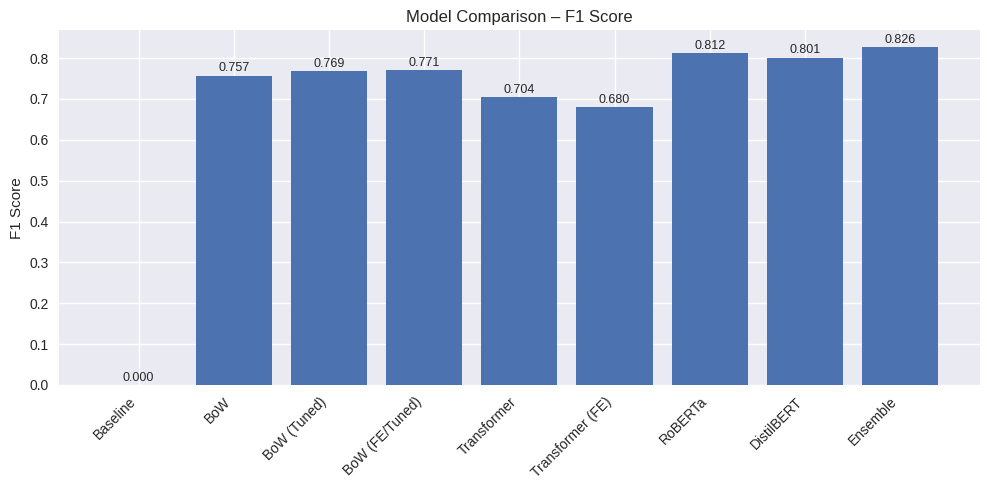

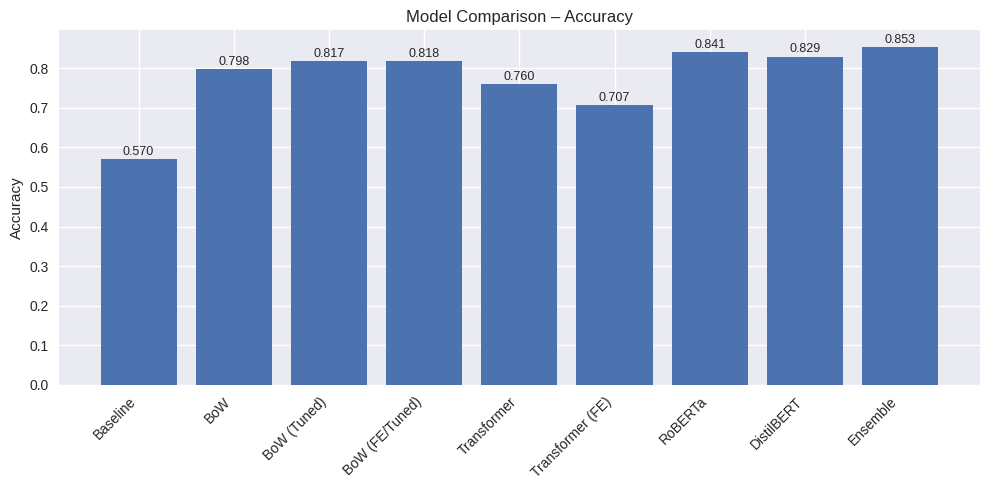

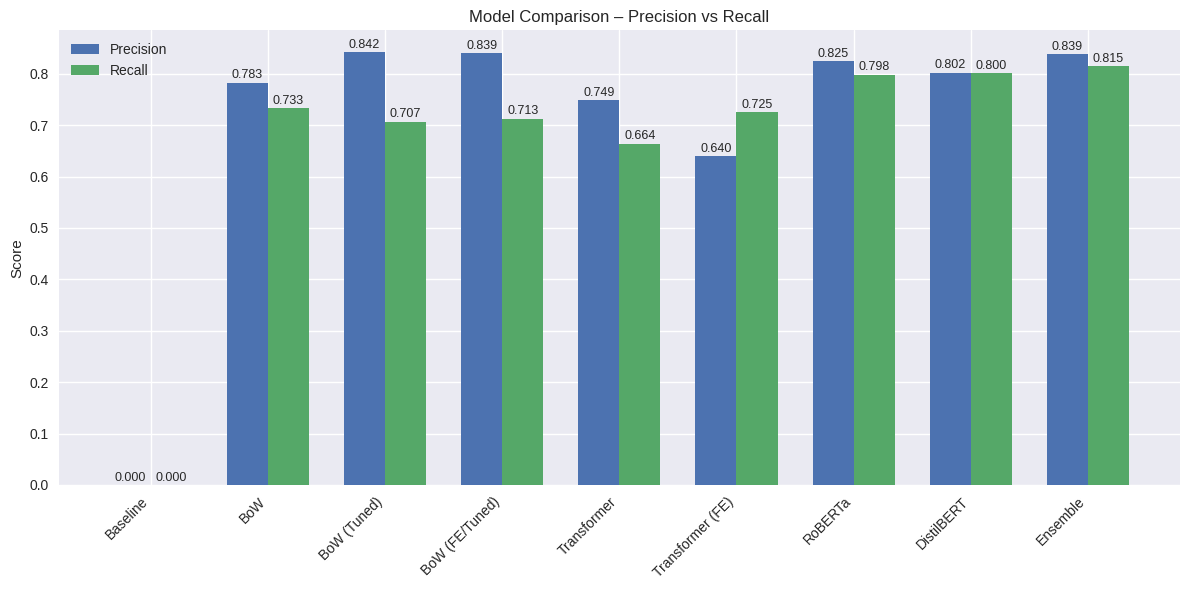

In [ ]:
# extract results
model_names  = [m["model"] for m in master_list]
f1_scores    = [m["f1"] for m in master_list]
acc_scores   = [m["accuracy"] for m in master_list]
prec_scores  = [m["precision"] for m in master_list]
recall_scores= [m["recall"] for m in master_list]

plt.style.use("seaborn-v0_8")

# function to add numbers on bars
def add_bar_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f"{height:.3f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha="center",
                     fontsize=9)

# 1. F1 scores
plt.figure(figsize=(10,5))
bars = plt.bar(model_names, f1_scores)
add_bar_labels(bars)
plt.ylabel("F1 Score")
plt.title("Model Comparison – F1 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Accuracy
plt.figure(figsize=(10,5))
bars = plt.bar(model_names, acc_scores)
add_bar_labels(bars)
plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. Precision vs Recall
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12,6))
bars1 = plt.bar(x - width/2, prec_scores, width, label="Precision")
bars2 = plt.bar(x + width/2, recall_scores, width, label="Recall")

add_bar_labels(bars1)
add_bar_labels(bars2)

plt.ylabel("Score")
plt.title("Model Comparison – Precision vs Recall")
plt.xticks(x, model_names, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
